# Principle Component Analysis Implementation (AY: 2025-26)

Sarvesh Vikas Tikekar (2022120037)

# **Introduction to PCA**

PCA stands for **Principal Component Analysis** is a dimensionality reduction technique used in data analysis and machine learning.

It helps you to reduce the number of features in a dataset while keeping the most important information by changing your original features into new features, where these new features don’t overlap with each other and the first few keep most of the important differences found in the original data.

PCA is commonly used for data preprocessing for use with machine learning algorithms. It helps to remove redundancy, improve computational efficiency and make data easier to visualize and analyze especially when dealing with high-dimensional data.

For the implementation of this algorithm, we would be making use of the **Pima Indians Diabetes Database/Dataset** from Kaggle

*  Link to Dataset: [Pima Diabetes Dataset](https://www.kaggle.com/datasets/mathchi/diabetes-data-set)


In [3]:
# Going to our actual project directory
%cd /content/drive/MyDrive/CSL701-Machine-Learning/
!pwd

/content/drive/MyDrive/CSL701-Machine-Learning
/content/drive/MyDrive/CSL701-Machine-Learning


In [4]:
!pip3 install scikit-learn

# **About the Dataset**

The Diabetes Dataset (Pima Indians) on Kaggle is a well-known dataset used for predicting the onset of diabetes in female patients of Pima Indian heritage, aged 21 or older.

It contains 768 records and 9 columns, including 8 diagnostic features such as Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age, with Outcome as the binary target variable indicating the presence (1) or absence (0) of diabetes.

This dataset is particularly suitable for classification tasks and for demonstrating data preprocessing, feature analysis, and predictive modeling.

The dataset is widely used in educational and research settings for tasks such as machine learning model building, feature engineering, and exploratory data analysis.

Overall, it provides a clean, structured tabular dataset ideal for testing classification algorithms and dimensionality reduction techniques like PCA.

In [13]:
# Importing all the libraries

import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from warnings import filterwarnings

filterwarnings("ignore")

In [14]:
# Declaring some global objects

std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

In [7]:
data = pd.read_csv("Datasets/diabetes.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [10]:
data.shape

(768, 9)

<Axes: >

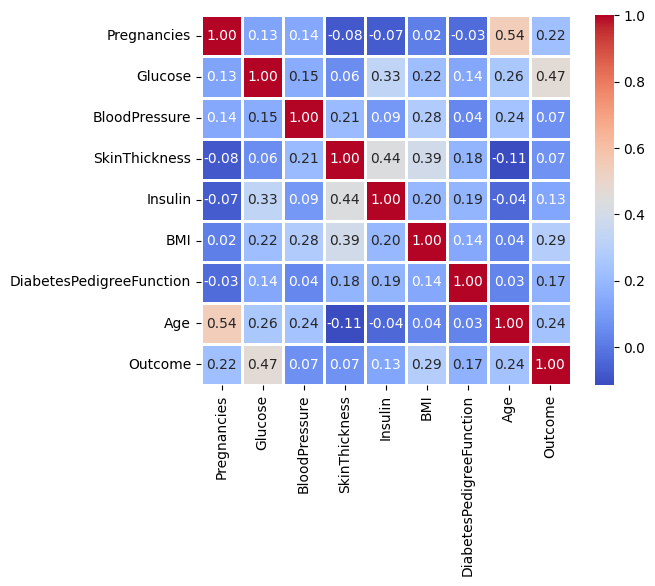

In [11]:
# Finding out the correlation matrix

cor = data.corr()
sns.heatmap(data=cor, cmap="coolwarm", square = True , annot=True, linewidths=0.75, fmt='.2f')

In [12]:
#Check for missing values

data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [25]:
# Standardizing the data (First seperating the features and the class)

X = data.drop(columns=['Outcome'])
y = data['Outcome']

x_standarised = std_scaler.fit_transform(X)
x_normalised = min_max_scaler.fit_transform(X)

print(f"Standardized Data: \n {x_standarised}")
print(f"Normalised Data: \n {x_normalised}")
print()
print(f"Data shapes are: {x_standarised.shape} and {x_normalised.shape}")


Standardized Data: 
 [[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
Normalised Data: 
 [[0.35294118 0.74371859 0.59016393 ... 0.50074516 0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 ... 0.39642325 0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 ... 0.34724292 0.25362938 0.18333333]
 ...
 [0.29411765 0.6080402  0.59016393 ... 0.390462   0.07130658 0.15      ]
 [0.05882353 0.63316583 0.49180328 ... 0.4485842  0.11571307 0.43333333]
 [0.05882353 0.46733668 0.57377049 ... 0.45305514 0.10119556 0.03333333]]

Data shapes are: (768, 

In [26]:
# Calculating the covariance matrix

X = x_standarised
cov_m = np.cov(X.T)

print(f"Covariance matrix is: \n {cov_m} \n and its shape is {cov_m.shape}")

Covariance matrix is: 
 [[ 1.00130378  0.12962746  0.14146618 -0.08177826 -0.07363049  0.01770615
  -0.03356638  0.54505093]
 [ 0.12962746  1.00130378  0.15278853  0.05740263  0.33178913  0.2213593
   0.13751636  0.26385788]
 [ 0.14146618  0.15278853  1.00130378  0.2076409   0.08904933  0.2821727
   0.04131875  0.23984024]
 [-0.08177826  0.05740263  0.2076409   1.00130378  0.43735204  0.39308503
   0.18416737 -0.11411885]
 [-0.07363049  0.33178913  0.08904933  0.43735204  1.00130378  0.19811702
   0.18531222 -0.04221793]
 [ 0.01770615  0.2213593   0.2821727   0.39308503  0.19811702  1.00130378
   0.14083033  0.03628912]
 [-0.03356638  0.13751636  0.04131875  0.18416737  0.18531222  0.14083033
   1.00130378  0.03360507]
 [ 0.54505093  0.26385788  0.23984024 -0.11411885 -0.04221793  0.03628912
   0.03360507  1.00130378]] 
 and its shape is (8, 8)


In [27]:
# Eigen value and vector Decomposition

eigen_values, eigen_vectors = np.linalg.eig(cov_m)
print("\nEigenvalues:\n", eigen_values)
print("\nEigenvectors (each column corresponds to an eigenvalue):\n", eigen_vectors)


Eigenvalues:
 [2.09711056 1.73346726 0.42036353 0.40498938 0.68351839 0.76333832
 0.87667054 1.03097228]

Eigenvectors (each column corresponds to an eigenvalue):
 [[-0.1284321  -0.59378583 -0.58879003  0.11784098 -0.19359817  0.47560573
  -0.08069115  0.01308692]
 [-0.39308257 -0.17402908 -0.06015291  0.45035526 -0.09416176 -0.46632804
   0.40432871 -0.46792282]
 [-0.36000261 -0.18389207 -0.19211793 -0.01129554  0.6341159  -0.32795306
  -0.05598649  0.53549442]
 [-0.43982428  0.33196534  0.28221253  0.5662838  -0.00958944  0.48786206
  -0.03797608  0.2376738 ]
 [-0.43502617  0.25078106 -0.13200992 -0.54862138  0.27065061  0.34693481
   0.34994376 -0.33670893]
 [-0.45194134  0.1009598  -0.03536644 -0.34151764 -0.68537218 -0.25320376
  -0.05364595  0.36186463]
 [-0.27061144  0.122069   -0.08609107 -0.00825873  0.08578409 -0.11981049
  -0.8336801  -0.43318905]
 [-0.19802707 -0.62058853  0.71208542 -0.21166198  0.03335717  0.10928996
  -0.0712006  -0.07524755]]


In [28]:
# Explained Variance

explained_variance = eigen_values / np.sum(eigen_values)
print("\nExplained Variance Ratio:\n", explained_variance)
print("Total variance explained by first 2 components:", np.sum(explained_variance[:2]))


Explained Variance Ratio:
 [0.26179749 0.21640127 0.05247702 0.05055776 0.08532855 0.09529305
 0.10944113 0.12870373]
Total variance explained by first 2 components: 0.4781987607385655


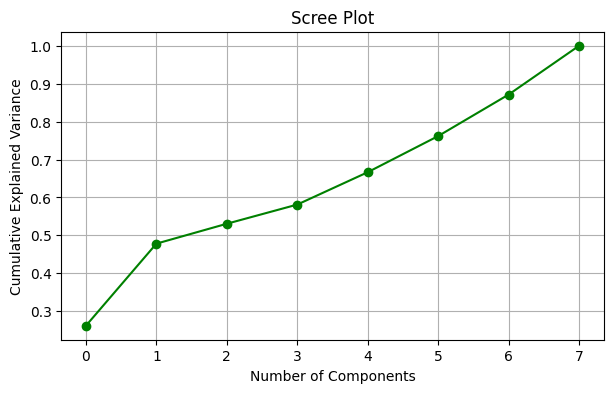

In [31]:
# Plotting the explained variance

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(explained_variance), marker='o', color='green')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

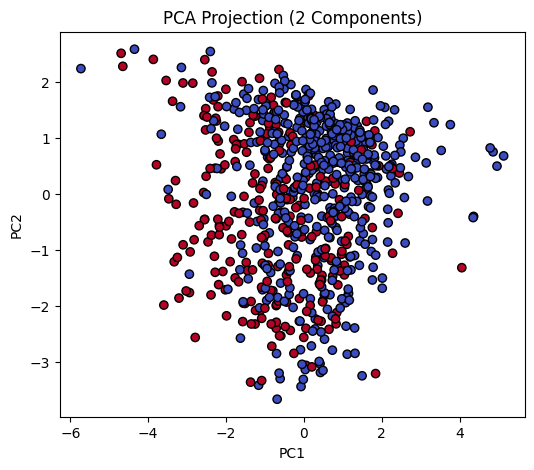

In [30]:
# Transform Data onto Top 2 Principal Components
idxs = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[idxs]
eigen_vectors = eigen_vectors[:, idxs]

k = 2
W = eigen_vectors[:, :k]
X_pca = X.dot(W)


plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("PCA Projection (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()